##

1. Raw choices
2. Probit --> 
    * remove subjects? (all other analysis in supplements)
    * 

In [1]:
import pandas as pd
import numpy as np
import os.path as op
import seaborn as sns
import pingouin
import matplotlib.pyplot as plt

phenotype_folder = '/Users/mrenke/data/ds-dnumrisk/derivatives/phenotype'
plot_folder ='/Users/mrenke/data/ds-dnumrisk/plots_and_ims/correlations_across_measures'
plot_folder_paper = '/Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_risk' 

df_participants = pd.read_csv(op.join('/Users/mrenke/data/ds-dnumrisk/add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
df_participants = df_participants.loc[:,['subject ID', 'age','group','gender']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
df_participants['group'] = np.where(df_participants['group'] == 0, 'control', 'dyscalc')

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
from numrisk.behavior_risk.utils import get_data

df = get_data()
df['x'] = df['log(risky/safe)']
df['group'] = np.where(df['group'] == 0, 'Control', 'Dyscalculic')

df = df.sort_index()

number of subjects in dataframe: 66
Int64Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
            18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
            35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
            52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
           dtype='int64', name='subject')


### Raw choices

In [99]:
def annotate_ttest(ax, x1, x2, y, h, text):
    # h = height of text compared to line
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, color='k')
    ax.text((x1+x2)*.5, y+h*1.2, text, ha='center', va='bottom', color='k')

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_10464/262970081.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = df_raw.groupby(['subject','group','format']).mean()


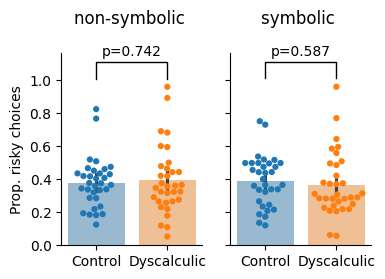

In [ ]:
import pingouin as pg

y_var = 'chose_risky'
df_raw = df.copy()
df_raw['group'] = np.where(df_raw['group'] == 0, 'Control', 'Dyscalculiculic')
tmp = df_raw.groupby(['subject','group','format']).mean()

col_var_list = tmp.index.unique('format')
fig, ax = plt.subplots(1,len(col_var_list),figsize=(4.,2.5), sharey=True)

for i, col_var in enumerate(col_var_list):

    filtered_data = tmp.xs(col_var,0,'format').reset_index()

    sns.barplot(ax=ax[i], data=filtered_data, x='group', hue='group', y=y_var, alpha=0.5)
    sns.swarmplot(ax=ax[i], data=filtered_data, x='group',  hue='group', y=y_var, size=4.5)

    an = pg.anova(data=filtered_data, dv=y_var, between='group')
    p_val = np.round(an['p-unc'][0],3)
    ax[i].set(title=f'{col_var} \n ' , xlabel=None) # ylim=(0.5,1.05),
    ax[i].set(ylabel='Prop. risky choices') if i == 0 else ax[i].set(ylabel=None)

    sns.despine()

    # after drawing bars/points
    ymax = filtered_data[y_var].max()
    annotate_ttest(ax[i], 0, 1, ymax + 0.05, 0.1, f"p={p_val:.3f}")
#plt.savefig(op.join(plot_folder_paper, 'raw_behavior_risk_group_comparison.pdf'), bbox_inches='tight')

Stake Size at bottom

#### argue to remove subjects where there is no evidence for taking ratio into account

-- `behavior_risk/paper_risk_01.ipynb`

## Probit

overview of regressors:
`/Users/mrenke/data/ds-dnumrisk/plots_and_ims/behavior_risk/rnp_model-3_format-both_regressors.pdf`

except RNP, so get RNPxSSxformatxgroup = 
* RNP | RNP:format | RNP:group
* RNP:SS | RNP:SS:format | RNP:SS:group

In [ ]:
import bambi
import arviz as az

# ── Configuration ────────────────────────────────────────────────────────────
# All have stake-size (model- 0/1 without for defining subjecst to remove, in `behavior_risk/paper_risk_01.ipynb`
# model-3 = both formats
# model-2 = symbolic format only
# rem1 = remove 5 subjects with no evidence for taking ratio into account (32, 40, 45, 46, 50) 

MODEL_CONFIGS = {
    '3': dict(
        formula = 'chose_risky ~ x + x*group*format*n_safe + (x*format*n_safe|subject)',
        format  = 'both',
    ),
    '3rem1': dict(
        formula        = 'chose_risky ~ x + x*group*format*n_safe + (x*format*n_safe|subject)',
        format         = 'both',
        subjects_remove = [32, 40, 45, 46, 50],
    ),
    '2': dict(
        formula = 'chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)',
        format  = 'symbolic',
    ),
    '2rem1': dict(
        formula         = 'chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)',
        format          = 'symbolic',
        subjects_remove = [32, 40, 45, 46, 50],
    ),}

BIDS_FOLDER = {
    'server': '/Volumes/g_econ_department$/projects/2023/renkert_dehollander_ruff_dnumr/data/ds-dnumrisk',
    'local':  '/Users/mrenke/data/ds-dnumrisk',}



In [ ]:
MODEL_LABEL = '3'  # ← change this to switch model versions
MACHINE = 'server'  # 'server' or 'local' | copy between machines due to storage issues with traces which are huuuggeee

# ── Load model & traces ───────────────────────────────────────────────────────

cfg          = MODEL_CONFIGS[MODEL_LABEL]
bids_folder  = BIDS_FOLDER[MACHINE]
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')

# Filter subjects if needed
subjects_remove = cfg.get('subjects_remove', [])
df_model = (df.loc[~df.index.get_level_values('subject').isin(subjects_remove)]
            if subjects_remove else df)

model  = bambi.Model(cfg['formula'], link='probit', family='bernoulli', data=df_model.reset_index())
traces = az.from_netcdf(op.join(trace_folder, f'model-{MODEL_LABEL}_format-{cfg["format"]}_trace.netcdf'))

In [20]:
# SS-RNP effect general and in each format separately
from itertools import product
from numrisk.behavior_risk.utils import extract_rnp_precision

intercept, gamma = extract_rnp_precision(traces, model, df, group_level = True) # 
rnp = np.clip(np.exp(intercept/gamma), 0, 1)
rnp = rnp.stack([1,2])
rnp.columns = ['rnp']

In [23]:
from utils_riskBehav import save_rnp_effects

format =MODEL_CONFIGS[MODEL_LABEL]['format']
save_rnp_effects(rnp, model_name = f'{MODEL_LABEL}_{format}', csv_path=op.join(plot_folder_paper, 'rnp_effects.csv'))

Saved 7 effects for '3_both' → /Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_risk/rnp_effects.csv


,model,effect,mean,ci_low,ci_high,p_gt_0
0,3_both,RNP,0.389907,0.255451,0.556684,1.000
1,3_both,RNP:format,-0.003655,-0.150776,0.110528,0.541
2,3_both,RNP:group,-0.020025,-0.139796,0.116611,0.363
3,3_both,RNP:SS,0.005232,0.002802,0.007577,1.000
4,3_both,RNP:SS:group,0.001642,-0.002049,0.005264,0.818
5,3_both,RNP:SS:format,0.008056,0.006363,0.009710,1.000
6,3_both,RNP:SS:format:group,0.001051,-0.002229,0.004383,0.736


OLD

In [ ]:
sub_removed = False
bids_folder = '/Volumes/g_econ_department$/projects/2023/renkert_dehollander_ruff_dnumr/data/ds-dnumrisk'
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')

model_label = '3'
format = 'both'
model = bambi.Model('chose_risky ~ x + x*group*format*n_safe + (x*format*n_safe|subject)', link='probit', family='bernoulli', data=df.reset_index())
traces = az.from_netcdf( op.join(trace_folder, f'model-{model_label}_format-{format}_trace.netcdf'))



In [ ]:
sub_removed = True
bids_folder = '/Users/mrenke/data/ds-dnumrisk'
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')

model_label = '3rem1'
format = 'both'
subList_remove = [32,40,45,46,50]
df_fil = df.loc[~df.index.get_level_values('subject').isin(subList_remove)] # only 10 subs to check model fitting
model = bambi.Model('chose_risky ~ x + x*group*format*n_safe + (x*format*n_safe|subject)', link='probit', family='bernoulli', data=df_fil.reset_index())

traces = az.from_netcdf( op.join(trace_folder, f'model-{model_label}_format-{format}_trace.netcdf'))


In [15]:
bids_folder = '/Volumes/g_econ_department$/projects/2023/renkert_dehollander_ruff_dnumr/data/ds-dnumrisk'
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')

model_label = '2'
sub_removed = False
format = 'symbolic'

model = bambi.Model('chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)', link='probit', family='bernoulli', data=df.reset_index())
traces = az.from_netcdf( op.join(trace_folder, f'model-{model_label}_format-{format}_trace.netcdf'))


In [13]:
bids_folder = '/Users/mrenke/data/ds-dnumrisk'
trace_folder = op.join(bids_folder, 'derivatives', 'cogmodels_risk')

model_label = '2rem1'
sub_removed = True
format = 'symbolic'

subList_remove = [32,40,45,46,50]
df_fil = df.loc[~df.index.get_level_values('subject').isin(subList_remove)] # only 10 subs to check model fitting
model = bambi.Model('chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)', link='probit', family='bernoulli', data=df_fil.reset_index())
traces = az.from_netcdf( op.join(trace_folder, f'model-{model_label}_format-{format}_trace.netcdf'))


In [9]:
from utils_riskBehav import save_rnp_effects

save_rnp_effects(rnp, model_name = f'{model_label}_{format}', csv_path=op.join(plot_folder_paper, 'rnp_effects.csv'))

Saved 7 effects for '2rem1_symbolic' → /Users/mrenke/data/ds-dnumrisk/plots_and_ims/paper_risk/rnp_effects.csv


,model,effect,mean,ci_low,ci_high,p_gt_0
0,2rem1_symbolic,RNP,0.392997,0.248240,0.575311,1.000
1,2rem1_symbolic,RNP:format,0.000000,0.000000,0.000000,0.000
2,2rem1_symbolic,RNP:group,-0.024778,-0.125449,0.086541,0.313
3,2rem1_symbolic,RNP:SS,0.008866,0.007087,0.010691,1.000
4,2rem1_symbolic,RNP:SS:group,0.002768,0.000107,0.005396,0.979
5,2rem1_symbolic,RNP:SS:format,0.000000,0.000000,0.000000,0.000
6,2rem1_symbolic,RNP:SS:format:group,0.000000,0.000000,0.000000,0.000


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return m

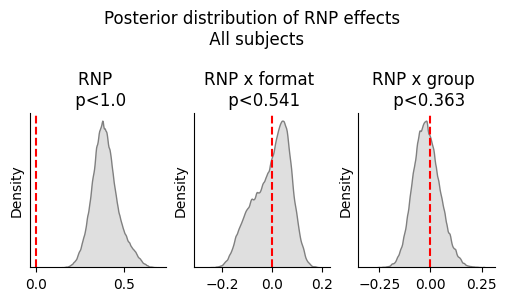

In [112]:
rnp_traces = [rnp, # RNP
              rnp.xs('non-symbolic',0,'format') - rnp.xs('symbolic',0,'format'), # RNPxformat
              rnp.xs(1,0,'group') - rnp.xs(0,0,'group')] # RNPxgroup
reg_list = ['RNP', 'RNP x format', 'RNP x group']

fig, axs = plt.subplots(1,3, figsize=(6,2), sharex=False)
for i, posterior_chain in enumerate(rnp_traces):
    count_greater_zero = np.round(np.mean(posterior_chain > 0),3)[0]

    sns.kdeplot(posterior_chain['rnp'], ax=axs[i],legend=False, fill=True, color='grey')
    axs[i].set(yticks=[],ylabel='Density', xlabel = '')
    axs[i].axvline(x=0, color='r', linestyle='--')
    axs[i].set_title(f'{reg_list[i]} \n p<{count_greater_zero}')
fig.suptitle(f'Posterior distribution of RNP effects \n {trace_name}', y=1.4)
sns.despine()
plt.savefig(op.join(plot_folder_paper, f'probit_RNP_model-{model_label}_format-{format}.pdf'), bbox_inches='tight')

In [ ]:
# RNPxSS effect general
n_chains = rnp.index.unique('chain').values
n_draws = rnp.index.unique('draw').values
index = pd.MultiIndex.from_product([n_chains, n_draws], names=['chain', 'draw'])
# get general stake-size:RNP effect

df_ss_rnp = pd.DataFrame(index=index, columns=['slope', 'intercept'])
for chain, draw in product(n_chains, n_draws):
    rnp_sample = rnp.xs(chain, level='chain').xs(draw, level='draw').reset_index('n_safe')

    tmp = rnp_sample.xs('Control',0,level='group') # general RNPxSS effect, reference level (same it coded as 0/1 or control/dyscalc, though the former will be numeric and the second categorical, but as C comes beofre D in alphabet, it should be the reference level)
    A1 = np.vstack([tmp['n_safe'], np.ones(len(tmp))]).T
    slope0, intercept0 = np.linalg.lstsq(A1, tmp['rnp'], rcond=None)[0]

    df_ss_rnp.loc[(chain, draw), 'slope'] = slope0
    df_ss_rnp.loc[(chain, draw), 'intercept'] = intercept0

temp = df_ss_rnp['slope']
print(f'mean={temp.mean()}, 95%CI={np.percentile(temp, [2.5, 97.5])}')

# 3 mins

mean=0.005231570580233986, 95%CI=[0.0028022380270550673 0.007576689845235379]


In [92]:
# RNPxSSxGroup effect 

df_slope_diffs = pd.DataFrame(index=index, columns=['slope_difference', 'intercept_difference'])

for chain, draw in product(n_chains, n_draws):
    rnp_sample = rnp.xs(chain, level='chain').xs(draw, level='draw').reset_index('n_safe')

    tmp = rnp_sample.xs('Control',0,level='group')
    A1 = np.vstack([tmp['n_safe'], np.ones(len(tmp))]).T
    slope0, intercept0 = np.linalg.lstsq(A1, tmp['rnp'], rcond=None)[0]

    tmp = rnp_sample.xs('Dyscalculic',0,level='group')
    A1 = np.vstack([tmp['n_safe'], np.ones(len(tmp))]).T
    slope1, intercept1 = np.linalg.lstsq(A1, tmp['rnp'], rcond=None)[0]

    slope_differences = slope1 - slope0
    int_differences = intercept1 - intercept0

    df_slope_diffs.loc[(chain, draw), 'slope_difference'] = slope_differences
    df_slope_diffs.loc[(chain, draw), 'intercept_difference'] = int_differences

temp = df_slope_diffs['slope_difference']
count_greater_zero = np.round(np.mean(temp > 0),3)
print(f'mean={temp.mean()}, 95%CI={np.percentile(temp, [2.5, 97.5])}')



mean=0.0016421110567357532, 95%CI=[-0.0020494638681192007 0.005264448472481931]


In [93]:
# RNPxSSxformat effect 

df_slope_diffs = pd.DataFrame(index=index, columns=['slope_difference', 'intercept_difference'])

for chain, draw in product(n_chains, n_draws):
    rnp_sample = rnp.xs(chain, level='chain').xs(draw, level='draw').reset_index('n_safe')

    tmp = rnp_sample.xs('non-symbolic',0,level='format')
    A1 = np.vstack([tmp['n_safe'], np.ones(len(tmp))]).T
    slope0, intercept0 = np.linalg.lstsq(A1, tmp['rnp'], rcond=None)[0]

    tmp = rnp_sample.xs('symbolic',0,level='format')
    A1 = np.vstack([tmp['n_safe'], np.ones(len(tmp))]).T
    slope1, intercept1 = np.linalg.lstsq(A1, tmp['rnp'], rcond=None)[0]

    slope_differences = slope1 - slope0
    int_differences = intercept1 - intercept0

    df_slope_diffs.loc[(chain, draw), 'slope_difference'] = slope_differences
    df_slope_diffs.loc[(chain, draw), 'intercept_difference'] = int_differences

temp = df_slope_diffs['slope_difference']
count_greater_zero = np.round(np.mean(temp > 0),3)
print(f'mean={temp.mean()}, 95%CI={np.percentile(temp, [2.5, 97.5])}')


mean=0.008055910047714542, 95%CI=[0.006362953166386923 0.009710331346769458]


In [ ]:
# RNPxSSxformatxgroup effect --- but maybe here we have to model different formats separately for 3-way-interactions?


## Stake Size effect in raw data

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_10464/3433662464.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = df.groupby(['subject','group','format','n_safe']).mean()


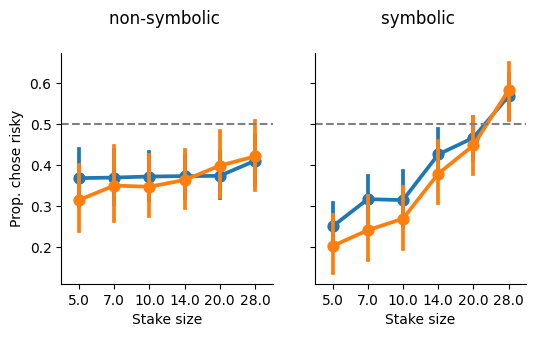

In [ ]:
x_var = 'n_safe'
hue = 'group'
y_var = 'chose_risky'

tmp = df.groupby(['subject','group','format','n_safe']).mean()
subList_remove = [40,46,50]
tmp = tmp[~tmp.index.get_level_values('subject').isin(subList_remove)]

col_var_list = df.index.unique('format')
fig, axs = plt.subplots(1,len(col_var_list),figsize=(6,3), sharey=True)

for i, col_var in enumerate(col_var_list):
    filtered_data = tmp.xs(col_var,0,'format').reset_index()

    sns.pointplot(data=filtered_data, x=x_var, y=y_var, hue=hue, errorbar='ci', legend=False, ax=axs[i]) #  col='age',
    sns.despine()
    axs[i].set(title=f'{col_var} \n ' , xlabel='Stake size', ylabel=None) # ylim=(0.5,1.05),
    axs[i].set_ylabel('Prop. chose risky')
    axs[i].axhline(y=0.5,color='grey', ls='--')
    #plt.savefig(op.join(plot_folder, 'risk_raw-chose-risky_stake-size.pdf'), bbox_inches='tight')



## Correlations

- stake_size_x_RNP ~ duration_option_diff_abs (without 5 subs ?!)
- n1_slope (WM - magjudge) ~ duration_option_diff_abs

In [ ]:
import itertools
import scipy.stats as stats
import pingouin

# eyetracking (only non-symbolic format)
format = 'non-symbolic'  # 'symbolic' or 'non-symbolic'
eyetrack_dur_diff = pd.read_csv(op.join(phenotype_folder, f'subwise_duration_option_difference_abs_{format}.tsv')).set_index('subject')


In [63]:
magjudge_probit_params = pd.read_csv(op.join(source_folder,'probit-2_all-subwise-params_appropSample.csv')).set_index('subject')

model_label =3 # 1 n1_evidence_sd & n2_evidence_sd, 3 = memory_noise_sd & perceptual_noise_sd
unbiased = '_unbiased' #'' # 
magjudge_bauer_params = pd.read_csv(op.join(source_folder,f'magjudge_bauer-{model_label}_sds{unbiased}.csv')).set_index('subject')

#magjudge_bauer_params.head()
# magjudge_probit_params.rename(columns={'n1_slope':'magjudge_number_range_order'})

In [11]:
# risk symbolic: SS (stake size) RNP slope
ss_rnp_slope =  pd.read_csv(op.join(source_folder,f'risk_SS-RNP-subwise-MAPs_probit-2_format-symbolic.csv'))
ss_rnp_slope = ss_rnp_slope.set_index('subject').rename(columns={'slope':'ss_rnp_slope'})[['ss_rnp_slope']]

In [12]:
# eyetracking (only smybolic format)
format = 'non-symbolic'  # 'symbolic' or 'non-symbolic'
eyetrack_dur_diff = pd.read_csv(op.join(source_folder, f'subwise_duration_option_difference_abs_{format}.tsv')).set_index('subject')


In [22]:
df_comb = magjudge_probit_params[['n1_slope']].join(ss_rnp_slope).join(eyetrack_dur_diff).join(df_participants['group'])

In [64]:
df_comb = magjudge_bauer_params[['memory_noise_sd']].join(ss_rnp_slope).join(eyetrack_dur_diff).join(df_participants['group'])

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

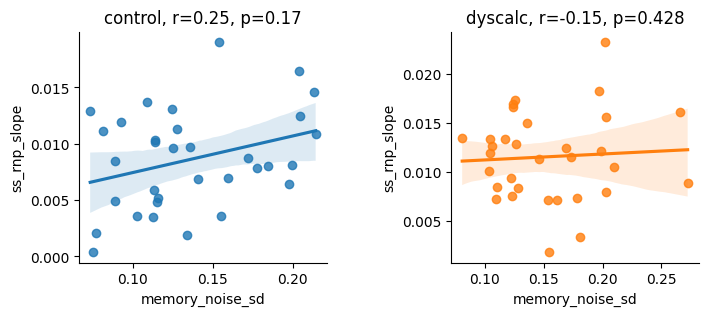

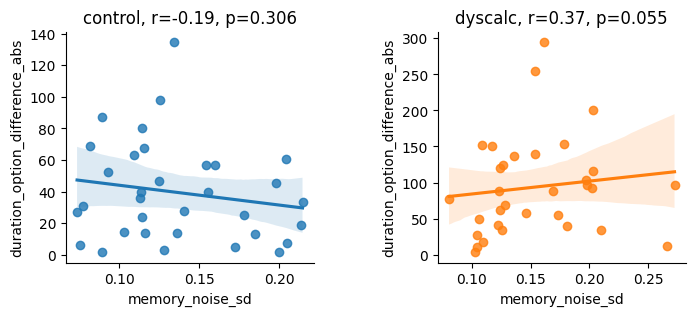

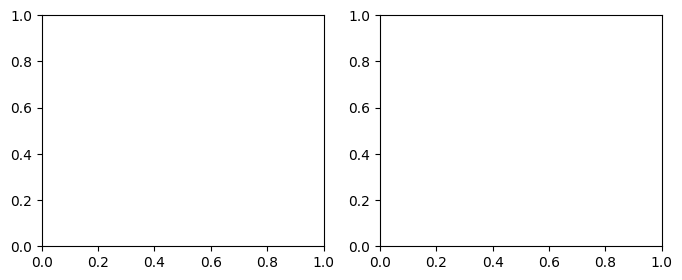

In [69]:
# groups separately

colors = [sns.color_palette()[0], sns.color_palette()[1]]
tmp = df_comb.drop(labels=46,axis=0)

vars = df_comb.columns.drop(['group'])

for x_var, y_var in itertools.combinations(vars, 2):
    fig,ax = plt.subplots(1,2, figsize=(8,3))

    for i,group in enumerate(tmp['group'].unique()):
        cor = pingouin.corr(tmp.loc[tmp['group'] == group, y_var], tmp.loc[tmp['group'] == group, x_var], method = 'shepherd')
        r_ = np.round(cor['r'][0], 2)
        p = np.round(cor['p-val'][0], 3)

        sns.regplot(x=x_var, y=y_var, data=tmp[tmp['group'] == group], ax=ax[i], color=colors[i])
        ax[i].set(title=f'{group}, r={r_}, p={p}', ylabel=y_var, xlabel=x_var)
        sns.despine()

    plt.subplots_adjust(wspace=0.5)
    #plt.savefig(op.join(plot_folder, f'corr_groups-seperate_{x_var}_vs_{y_var}.png'))

In [43]:
# Miguels data

phenotype_folder_miguel = '/Users/mrenke/data/ds-miguel/derivatives/phenotype'
miguel_risk = pd.read_csv(op.join(phenotype_folder_miguel, 'risk_ss_rnp_subject_specific_model-2_format-symbolic.csv')).set_index('subject')
miguel_risk = miguel_risk.rename(columns={'slope':'ss_rnp_slope'})

miguel_magcomp =  pd.read_csv(op.join(phenotype_folder_miguel, 'probit_model-2_all-subwise-params.csv')).set_index('subject')
miguel_magcomp_bauer = pd.read_csv(op.join(phenotype_folder_miguel, 'bauer-3_sds-maps_unbiased.csv')).set_index('subject')

In [48]:
df_comb_miguel = miguel_magcomp[['n1_slope']].join(miguel_risk['ss_rnp_slope']).join(miguel_magcomp_bauer['memory_noise_sd'])
df_comb_miguel['ss_rnp_slope_abs'] = df_comb_miguel['ss_rnp_slope'].abs()

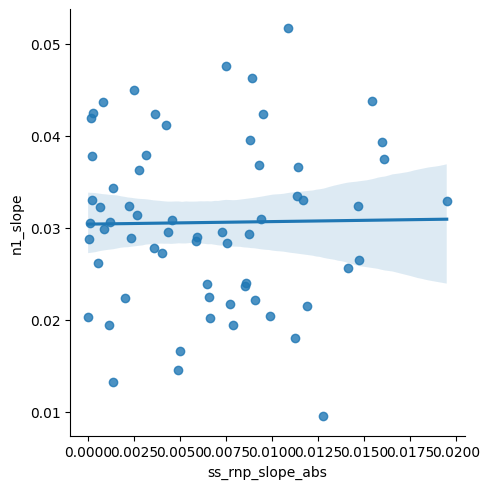

In [50]:
sns.lmplot(data=df_comb_miguel.reset_index(), x='ss_rnp_slope_abs', y='n1_slope')

In [65]:
df_comb_miguel['dataset'] = 'Miguel'
df_comb['dataset'] = 'Dnumrisk'

vars = ['ss_rnp_slope', 'memory_noise_sd']
df_general = pd.concat([df_comb_miguel.set_index('dataset',append=True)[vars], df_comb.set_index('dataset',append=True)[vars]], axis=0)

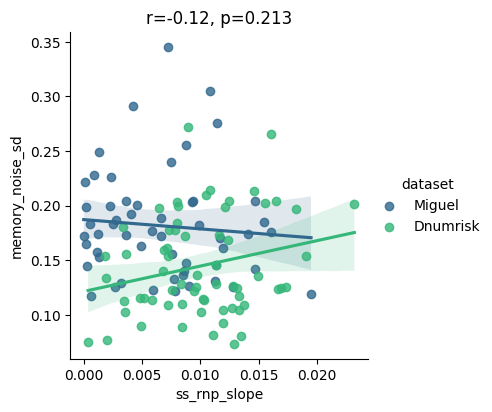

In [80]:
y_var = 'memory_noise_sd'
x_var = 'ss_rnp_slope'

tmp = df_general[df_general['ss_rnp_slope']>0]
cor = pingouin.corr(tmp[y_var], tmp[ x_var], method = 'shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)

fig = sns.lmplot(data=tmp.reset_index(), x='ss_rnp_slope', y='memory_noise_sd',hue='dataset', palette='viridis', height=4) 
ax = fig.axes[0,0]
ax.set(title=f'r={r_}, p={p}', ylabel=y_var, xlabel=x_var)
sns.despine()